# Grammar Scoring Engine for Spoken English
**SHL Hiring Assessment 2026** · predict a 1–5 grammar score (averaged rater MOS) from a 45–60 s audio answer.

**Approach in one line:** transcribe with Whisper, then combine *what was said* (grammar-aware text models)
with *how it was said* (frozen speech-encoder embeddings) in a small, cross-validated stack.

| | |
|---|---|
| Final model | 2-level stack of 4 parts: Whisper-large-v3 **encoder fine-tuned with LoRA** · DeBERTa-v3-large fine-tuned on transcripts (3 seeds) · fluency + grammar features · TF-IDF |
| Validation | 5-fold CV on the 732 valid training clips, stratified by recording batch and score; level-2 weights evaluated with **nested** CV |
| Metrics | RMSE (leaderboard metric) and Pearson r, overall, on the test-like 45 s batch, and re-weighted to the test set's batch mix |

**How this notebook is organised.** GPU-heavy steps (ASR, grammar models, DeBERTa fine-tuning, speech embeddings) ran as batch
jobs (`src/*.py`, `jobs/*.pbs`) and saved their outputs to `outputs/`. This notebook loads those outputs, re-runs every
CPU step (audio regressors, stacking, evaluation) with the same scripts, and checks at the end that it reproduces the
submitted files exactly.

In [1]:
import ast, json, re, subprocess, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

DATA, OUT = "data/Dataset_Final", "outputs"
TRANSCRIPTS = f"{OUT}/transcripts_fw_large_v3.jsonl"
pd.set_option("display.width", 160, "display.max_colwidth", 90)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
rmse = lambda y, p: float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

def run(cmd):
    # Run a pipeline script and return its stdout (warnings filtered) - the notebook uses the exact code that made the submission.
    out = subprocess.run([sys.executable, "-W", "ignore", *cmd.split()], capture_output=True, text=True)
    assert out.returncode == 0, out.stderr[-2000:]
    return out.stdout

## 1. The data — and three things that change the approach

769 labelled training clips, 216 test clips, grammar scores on a 1–5 rubric
(1 = struggles with basic structure … 5 = accurate, handles complex grammar, self-corrects).

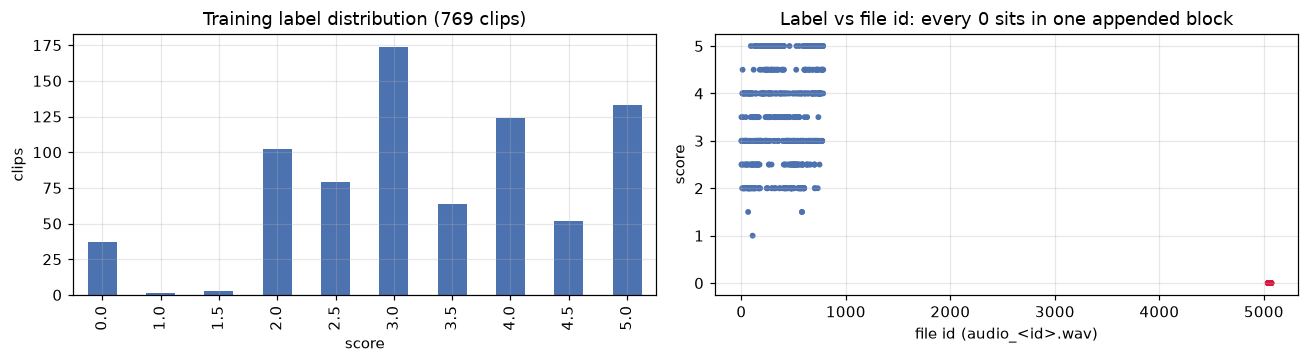

zero labels: 37 -> ids 5037..5073 (contiguous: True)
all other clips: ids 0..784, n=732, mean 3.48
test ids: [0, 215]


In [2]:
lab = pd.read_csv(f"{DATA}/train.csv")
lab["id"] = lab.filename.str.extract(r"(\d+)").astype(int)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
lab.label.value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set(title="Training label distribution (769 clips)", xlabel="score", ylabel="clips")
ax[1].scatter(lab.id, lab.label, s=8, c=np.where(lab.label == 0, "crimson", "#4C72B0"))
ax[1].set(title="Label vs file id: every 0 sits in one appended block", xlabel="file id (audio_<id>.wav)", ylabel="score")
plt.tight_layout(); plt.show()
zeros = lab[lab.label == 0]
print(f"zero labels: {len(zeros)} -> ids {zeros.id.min()}..{zeros.id.max()} (contiguous: {zeros.id.max() - zeros.id.min() + 1 == len(zeros)})")
print(f"all other clips: ids {lab[lab.label > 0].id.min()}..{lab[lab.label > 0].id.max()}, n={int((lab.label > 0).sum())}, mean {lab[lab.label > 0].label.mean():.2f}")
print("test ids:", pd.read_csv(f"{DATA}/test.csv").filename.str.extract(r"(\d+)").astype(int)[0].agg(["min", "max"]).tolist())

**Finding 1 — the 37 zero labels are missing ratings, not grammar scores.** A score of 0 is not on the rubric, all 37
zeros are the contiguous block `audio_5037 … audio_5073` appended after the normal files (ids 0–784, 732 files), and
their transcripts are ordinary, often fluent speech. The test files are numbered `audio_0 … audio_215`, so the test set
very likely contains no such block. **These 37 clips are excluded from training and validation**; keeping them would
teach the model that normal speech can score 0 and pull every prediction down (the effect on the metric is
quantified in §6).

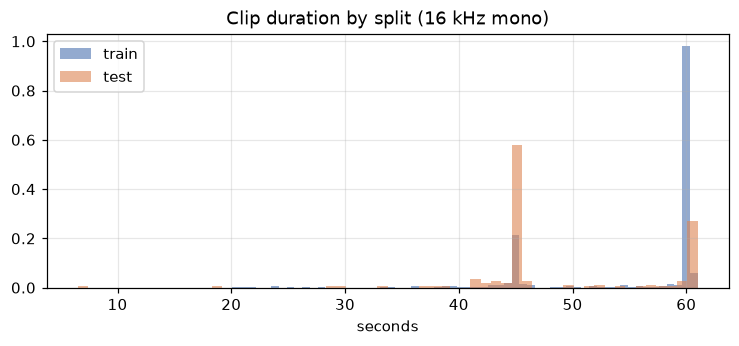

split  test share  train share
batch                         
45s          0.57         0.17
60s          0.27         0.72
other        0.16         0.12
       count  mean   std
batch                   
45s      126  3.04  0.88
60s      521  3.58  1.02
other     85  3.53  0.97


In [3]:
info = pd.read_csv(f"{OUT}/audio_info.csv").rename(columns={"fn": "filename"})
info["batch"] = np.select([info.dur.between(44, 46), info.dur > 59], ["45s", "60s"], "other")
fig, ax = plt.subplots(figsize=(8, 3))
for s, c in (("train", "#4C72B0"), ("test", "#DD8452")):
    ax.hist(info[info.split == s].dur, bins=60, alpha=.6, density=True, label=s, color=c)
ax.set(title="Clip duration by split (16 kHz mono)", xlabel="seconds"); ax.legend(); plt.show()
t = info[info.split == "train"].merge(lab[lab.label > 0], on="filename")
share = pd.crosstab(info.batch, info.split, normalize="columns").round(2)
print(share.rename(columns={"train": "train share", "test": "test share"}))
print(t.groupby("batch").label.agg(["count", "mean", "std"]).round(2))

**Finding 2 — two recording batches, and the test set is dominated by the smaller one.** ~57 % of test clips are ~45 s
long, versus only ~17 % of training clips; the 45 s batch also has lower, less spread-out scores. Consequences:
* all hand-crafted features are **normalised** (per minute / per 100 words) so they don't just encode clip length;
* CV folds are stratified by batch, and every model is also scored on the **45 s subset** and with a
  **test-mix-weighted RMSE** (each clip weighted by test share / train share of its batch) — our best leaderboard proxy;
* the final level-2 fit uses the same importance weights.

## 2. Pipeline

```
 wav ─► faster-whisper large-v3 ─► transcript + word timings + confidences
  │                                 ├─► fluency & text features (rate, pauses, repeats, ASR confidence, vocabulary)
  │                                 ├─► CoLA acceptability (RoBERTa-large) + grammar-correction edit rate (CoEdIT-large)
  │                                 ├─► TF-IDF ─► ridge
  │                                 └─► DeBERTa-v3-large fine-tuned regressor (5 folds × 3 seeds)
  └─► Whisper-large-v3 ENCODER + LoRA adapters, mean-pooled ─► regression head (fine-tuned, 5 folds)
                     all level-1 predictions are out-of-fold ─► non-negative weighted average (level 2)
```

| Step | Script | Where |
|---|---|---|
| ASR + word timestamps | `src/transcribe_fw.py` | GPU |
| CoLA + grammar correction | `src/grammar_features.py` | GPU |
| DeBERTa fine-tuning (OOF + test) | `src/text_model.py` | GPU |
| Speech-encoder fine-tuning (LoRA) | `src/audio_finetune.py` | GPU |
| Frozen speech-encoder embeddings (ablation) | `src/audio_embed.py` | GPU |
| Fluency features | `src/features.py` | CPU (this notebook) |
| Audio regressors | `src/audio_model.py` | CPU (this notebook) |
| Stacking, CV, submission | `src/train.py` | CPU (this notebook) |

The two neural components are fine-tuned with a **fixed number of epochs** (no per-fold early stopping, so their
out-of-fold predictions are honest): DeBERTa fully, the Whisper encoder only through LoRA adapters on its attention
projections (<1 % of its weights) - the right amount of capacity for 732 labels. The CoLA / grammar-correction models
and the ASR are used frozen.

## 3. Speech recognition — and what it hides

In [4]:
tx = pd.DataFrame([json.loads(l) for l in open(TRANSCRIPTS, encoding="utf-8")])
tr_tx = tx[tx.split == "train"].merge(lab[lab.label > 0], on="filename")
for _, r in tr_tx.sort_values("label").iloc[[5, len(tr_tx) // 2, -5]].iterrows():
    print(f"score {r.label}: " + " ".join(r.text.split()[:28]) + " ...")
words = tx.text.str.lower().str.findall(r"[a-z']+")
fill = words.apply(lambda w: sum(t in {"um", "uh", "er", "erm", "ah", "hmm"} for t in w) / max(len(w), 1) * 100)
print(f"\nfillers per 100 words (um/uh/...): mean {fill.mean():.3f}, clips with any: {(fill > 0).mean():.1%}")

score 2.0: My hobby is watching TV and web series and movies. I like the most about the NTR and his movies and his action. I like to cultivate the ...
score 3.5: life is full of events both good and bad some things will be forgotten over time and some will stay in our heart forever our life is full ...
score 5.0: Well, my favorite hobby is music, so yeah, I love playing music. I have a bass, I play bass. I like to kind of play with keyboards, do ...

fillers per 100 words (um/uh/...): mean 0.258, clips with any: 12.0%


**Finding 3 — Whisper cleans up speech.** Large-v3 keeps repetitions ("I have to I have to") but drops almost every
filled pause (≈0.06 "um/uh" per 100 words), so filler features computed from the transcript are nearly useless.
This is one reason the audio branch (which hears hesitations directly) adds so much in §5.

## 4. Hand-crafted fluency and grammar features

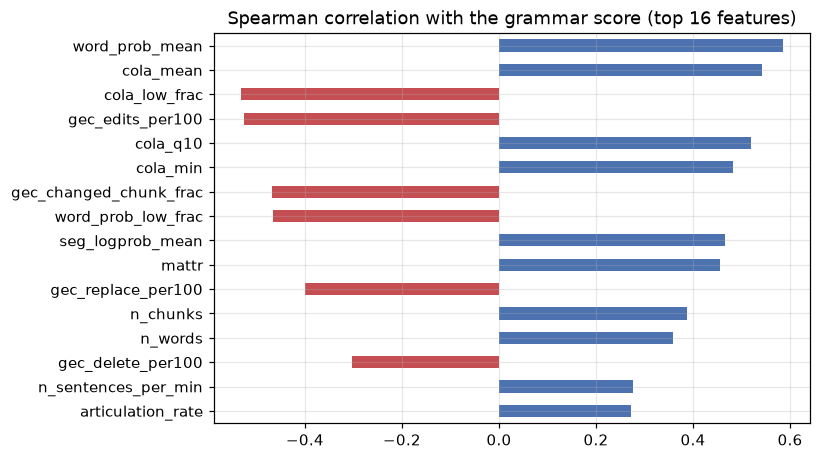

In [5]:
sys.path.insert(0, "src")
from features import load as load_features
feats, _ = load_features(TRANSCRIPTS)
feats = feats.merge(pd.read_csv(f"{OUT}/grammar_features.csv"), on=["filename", "split"])
ft = feats[feats.split == "train"].merge(lab[lab.label > 0], on="filename")
corr = ft.drop(columns=["filename", "split", "label", "id"]).corrwith(ft.label, method="spearman").dropna()
corr = corr.reindex(corr.abs().sort_values().index)[-16:]
corr.plot.barh(figsize=(7, 4.6), color=np.where(corr > 0, "#4C72B0", "#C44E52"),
               title="Spearman correlation with the grammar score (top 16 features)"); plt.show()

In [6]:
pairs = [json.loads(l) for l in open(f"{OUT}/gec_corrections.jsonl", encoding="utf-8")]
shown = 0
for p in pairs:
    for src, tgt in p["pairs"]:
        s, t = re.findall(r"[a-z']+", src.lower()), re.findall(r"[a-z']+", tgt.lower())
        if 0 < sum(a != b for a, b in zip(s, t)) <= 2 and len(s) == len(t) and shown < 3:
            print("spoken   :", src[:110]); print("corrected:", tgt[:110], "\n"); shown += 1

spoken   : there was a day in the airport that I wanted to go with my mom to Panama in this day I was trying to buy
corrected: There was a day at the airport that I wanted to go with my mom to Panama. On this day, I was trying to buy 

spoken   : A lot of noise are in there.
corrected: A lot of noise is in there. 

spoken   : So if you are not good at noises, it is not for you.
corrected: So if you are not good at noise, it is not for you. 



Grammar-specific signals work as intended: the **grammar-correction edit rate** (edits per 100 words by CoEdIT,
punctuation/capitalisation ignored) and the **CoLA acceptability** scores are among the strongest single features,
alongside delivery measures (speech rate, pauses) and ASR confidence.

## 5. Component models and the stack

Each component produces **out-of-fold** predictions on the same 5 folds. The level-2 model is a non-negative weighted
average (+ intercept) fit with the batch importance weights; its CV score is **nested** (weights for fold *k* are fit
on the other four folds only). The audio regressors pick their layers *a priori* (upper layers of each encoder); the
per-layer tables are printed only as analysis.

In [7]:
for emb, layers, out in [("whisper_enc_emb", "25,26,27,28,29,30,31,32", "whisper_enc_preds"),
                         ("wavlm_large_emb", "13,14,15,16,17,18,19,20", "wavlm_large_preds")]:
    log = run(f"src/audio_model.py --emb {OUT}/{emb}.npz --labels {DATA}/train.csv --folds {OUT}/folds.csv "
              f"--layers {layers} --out {OUT}/{out}.csv")
    print(emb, "->", [l for l in log.splitlines() if "used" in l][0])

whisper_enc_emb -> layers [25, 26, 27, 28, 29, 30, 31, 32] (used): OOF RMSE 0.556  r 0.836


wavlm_large_emb -> layers [13, 14, 15, 16, 17, 18, 19, 20] (used): OOF RMSE 0.560  r 0.834


In [8]:
BASE = f"src/train.py --transcripts {TRANSCRIPTS} --labels {DATA}/train.csv --folds {OUT}/folds.csv --weighted --stack"
DEB_L = f"{OUT}/deberta_large_preds.csv {OUT}/deberta_large_s1.csv {OUT}/deberta_large_s2.csv"
DEB_B = f"{OUT}/deberta_preds.csv {OUT}/deberta_base_s1.csv {OUT}/deberta_base_s2.csv"
AVG_L = "deberta_large=deberta_large_preds,deberta_large_s1,deberta_large_s2"
AVG_B = "deberta_base=deberta_preds,deberta_base_s1,deberta_base_s2"
G = f"{OUT}/grammar_features.csv"
configs = {
    "features + TF-IDF + DeBERTa-L (text only)": f"--extra {G} {DEB_L} --avg {AVG_L}",
    "features + TF-IDF + Whisper-encoder (audio)": f"--extra {G} {OUT}/whisper_enc_preds.csv",
    "same, frozen Whisper encoder (sub05)": f"--extra {G} {DEB_L} {OUT}/whisper_enc_preds.csv --avg {AVG_L}",
    "FINAL: features + TF-IDF + DeBERTa-L + LoRA-Whisper": f"--extra {G} {DEB_L} {OUT}/whisper_ft_preds.csv --avg {AVG_L} --sub {OUT}/final_v9.csv",
    "v8: + DeBERTa-base + WavLM-base/large": f"--extra {G} {DEB_B} {DEB_L} {OUT}/wavlm_preds.csv {OUT}/wavlm_large_preds.csv "
                                            f"{OUT}/whisper_enc_preds.csv --avg {AVG_B} {AVG_L} --sub {OUT}/final_v8.csv",
}
LINE = re.compile(r"^\s*(component: )?(.+?)\s+RMSE ([\d.]+)\s+r ([\d.]+|nan) \| 45s: RMSE ([\d.]+) r ([\d.]+|nan) \| test-mix RMSE ([\d.]+)")
NICE = {"mean predictor": "mean predictor", "hand_features": "fluency + grammar features (ridge/HGB)", "tfidf": "TF-IDF + ridge",
        "deberta_base": "DeBERTa-v3-base (3 seeds)", "deberta_large": "DeBERTa-v3-large (3 seeds)", "wavlm_preds": "WavLM-base-plus + ridge",
        "wavlm_large_preds": "WavLM-large + ridge", "whisper_enc_preds": "Whisper-large-v3 encoder (frozen) + ridge",
        "whisper_ft_preds": "Whisper-large-v3 encoder, LoRA fine-tuned"}
rows, logs = {}, {}
for name, args in configs.items():
    logs[name] = run(f"{BASE} {args}")
    for l in logs[name].splitlines():
        m = LINE.match(l)
        if m and (m[1] or m[2].startswith("STACK") or m[2] == "mean predictor"):
            key = (f"STACK: {name}" if m[2].startswith("STACK") else
                   "baseline: mean predictor" if m[2] == "mean predictor" else "component: " + NICE.get(m[2], m[2]))
            rows[key] = [float(x) for x in m.groups()[2:]]
table = pd.DataFrame(rows, index=["CV RMSE", "CV r", "45s RMSE", "45s r", "test-mix RMSE"]).T
table = pd.concat([table[~table.index.str.startswith("STACK")].sort_values("test-mix RMSE", ascending=False),
                   table[table.index.str.startswith("STACK")]]).round(3)
table

,CV RMSE,CV r,45s RMSE,45s r,test-mix RMSE
baseline: mean predictor,1.014,NaN,0.986,NaN,0.994
component: TF-IDF + ridge,0.893,0.597,0.773,0.627,0.829
component: fluency + grammar features (ridge/HGB),0.654,0.765,0.671,0.660,0.666
component: WavLM-base-plus + ridge,0.598,0.808,0.736,0.593,0.664
component: WavLM-large + ridge,0.560,0.834,0.672,0.670,0.615
component: DeBERTa-v3-base (3 seeds),0.613,0.807,0.615,0.763,0.611
component: Whisper-large-v3 encoder (frozen) + ridge,0.556,0.836,0.609,0.723,0.583
component: DeBERTa-v3-large (3 seeds),0.583,0.825,0.587,0.771,0.576
"component: Whisper-large-v3 encoder, LoRA fine-tuned",0.552,0.839,0.582,0.751,0.566
STACK: features + TF-IDF + DeBERTa-L (text only),0.558,0.836,0.547,0.786,0.546


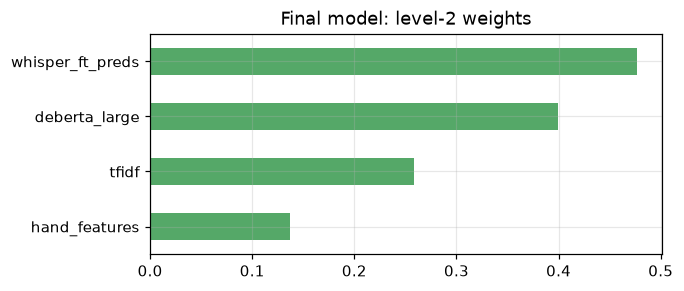

(weights sum to 1.27 with a negative intercept: the stack re-expands predictions that each component shrank toward the mean)


In [9]:
w = ast.literal_eval(re.search(r"level-2 weights: (\{.*?\})", logs["FINAL: features + TF-IDF + DeBERTa-L + LoRA-Whisper"])[1])
pd.Series(w).sort_values().plot.barh(figsize=(6, 2.6), color="#55A868", title="Final model: level-2 weights"); plt.show()
print("(weights sum to", round(sum(w.values()), 2), "with a negative intercept: the stack re-expands predictions that each component shrank toward the mean)")

**Reading the ablation.** Mean prediction scores RMSE ≈ 1.01. Each strong component alone reaches ~0.55–0.60.
Text (DeBERTa) is the strongest on the 45 s batch, audio (Whisper encoder) on the 60 s batch, so combining them helps
most. Fine-tuning the Whisper encoder with LoRA (instead of a frozen encoder + ridge) gives the final gain, mostly on
the 45 s batch that dominates the test set. The 4-part final model matches or beats the 7-part v8 stack, so we keep
the simpler one.
Notably, a frozen speech encoder alone rivals a fine-tuned text model: rater "grammar" judgements also reflect
fluency and delivery.

### What we tried that did not help (kept out of the final model)
| Idea | Result (test-mix CV RMSE, final model = 0.515) | Why we think so |
|---|---|---|
| Pause markers — `(pause)` > 250 ms, `(long pause)` > 1 s inserted into the DeBERTa transcripts | 0.516 as replacement, 0.517 as extra component | the audio branch already hears hesitations directly |
| Adding DeBERTa-base and WavLM-base/large to the 4-part stack (v8) | 0.518 | redundant with DeBERTa-large and the Whisper encoder |
| Per-batch linear recalibration of the stack's output | 0.549–0.553 (from 0.545 at the time) | out-of-fold predictions were already calibrated (slope ≈ 1 in every batch) |
| Gradient boosting over all features instead of the 2-level stack | 0.545 | re-learning 7 predictions + 30 features from 732 clips overfits; a non-negative weighted average does not |

## 6. Final metrics (including the required training RMSE)

In [10]:
log = logs["FINAL: features + TF-IDF + DeBERTa-L + LoRA-Whisper"]
train_rmse = float(re.search(r"training RMSE, stack \(in-sample\): ([\d.]+)", log)[1])
oof = pd.read_csv(f"{OUT}/final_v9.oof.csv")
cv_rmse, cv_r = rmse(oof.label, oof.oof), pearsonr(oof.label, oof.oof)[0]
# If the 37 zero-labelled clips were kept as real targets, a model predicting its usual ~3.3 for them would score:
p0 = oof.oof.mean()
with_zeros = float(np.sqrt((len(oof) * cv_rmse ** 2 + 37 * p0 ** 2) / (len(oof) + 37)))
print(f"TRAINING RMSE (final model refit on all 732 valid training clips, scored on those clips): {train_rmse:.3f}")
print("   note: level-2 is fit on the out-of-fold level-1 predictions, so this is an honest in-sample number for the stack")
print(f"CV RMSE (nested, 732 clips): {cv_rmse:.3f}   |   CV Pearson r: {cv_r:.3f}")
print(f"test-mix-weighted CV RMSE (leaderboard proxy): {float(np.sqrt(np.sum(oof.w * (oof.label - oof.oof) ** 2) / oof.w.sum())):.3f}")
print(f"for reference, RMSE over all 769 rows if the 37 zeros were scored as real labels: ~{with_zeros:.3f}")
print("public leaderboard (RMSE): final model (v9) 0.3392 · v8 0.3401 · frozen-encoder version 0.3443 (#1 on the public leaderboard)")

TRAINING RMSE (final model refit on all 732 valid training clips, scored on those clips): 0.512
   note: level-2 is fit on the out-of-fold level-1 predictions, so this is an honest in-sample number for the stack
CV RMSE (nested, 732 clips): 0.516   |   CV Pearson r: 0.861
test-mix-weighted CV RMSE (leaderboard proxy): 0.510
for reference, RMSE over all 769 rows if the 37 zeros were scored as real labels: ~0.913
public leaderboard (RMSE): final model (v9) 0.3392 · v8 0.3401 · frozen-encoder version 0.3443 (#1 on the public leaderboard)


## 7. Error analysis

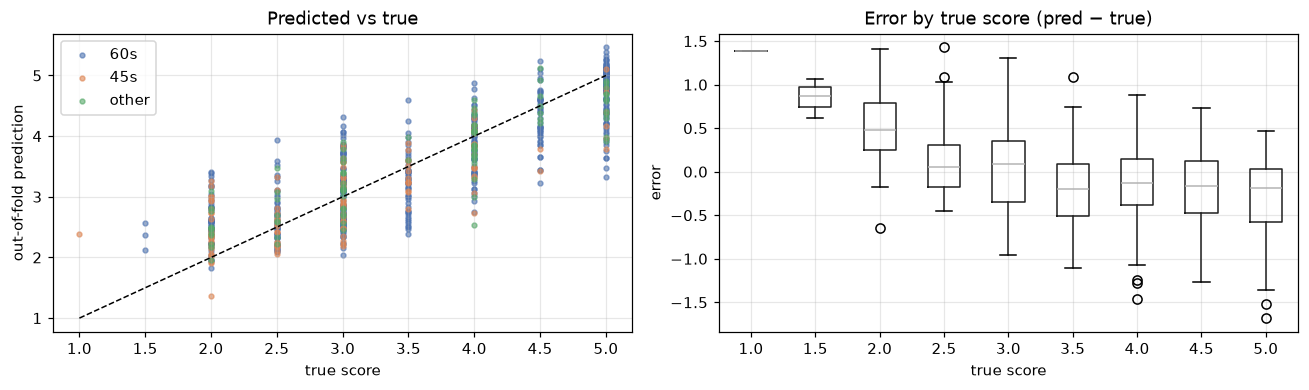

       count   mean   rmse
batch                     
45s      124  0.011  0.516
60s      521 -0.018  0.523
other     87  0.029  0.472


In [11]:
oof = oof.merge(tx[tx.split == "train"][["filename", "text"]], on="filename")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for b, c in (("60s", "#4C72B0"), ("45s", "#DD8452"), ("other", "#55A868")):
    m = oof.batch == b
    ax[0].scatter(oof.label[m], oof.oof[m], s=10, alpha=.6, label=b, color=c)
ax[0].plot([1, 5], [1, 5], "k--", lw=1); ax[0].set(xlabel="true score", ylabel="out-of-fold prediction", title="Predicted vs true"); ax[0].legend()
oof.assign(err=oof.oof - oof.label).boxplot(column="err", by="label", ax=ax[1])
ax[1].set(title="Error by true score (pred − true)", xlabel="true score", ylabel="error"); plt.suptitle(""); plt.tight_layout(); plt.show()
print(oof.assign(err=oof.oof - oof.label).groupby("batch").err.agg(["count", "mean", lambda e: np.sqrt(np.mean(e ** 2))]).rename(columns={"<lambda_0>": "rmse"}).round(3))

In [12]:
big = oof.assign(err=oof.oof - oof.label).reindex((oof.oof - oof.label).abs().sort_values(ascending=False).index).head(5)
for _, r in big.iterrows():
    print(f"true {r.label}  pred {r.oof:.2f}  ({r.batch}) | " + " ".join(r.text.split()[:22]) + " ...")

true 5.0  pred 3.32  (60s) | I'm gonna describe the scene of a crowded market. There is a market nearby where I live and I mostly go to ...
true 5.0  pred 3.48  (60s) | my favorite place to visit is the national park I like to visit a national park especially Kruger National Park because I'm ...
true 4.0  pred 2.53  (other) | The playground has many children. There are slides, seesaw, and different kind of playing activities. The noise from the playground are coming ...
true 2.5  pred 3.93  (60s) | I think the goal that I am achieving right now is to be happy, completely happy because I think in this generation ...
true 2.0  pred 3.41  (60s) | the school playground is a vibrant space teeming with energy and moment it afforded with colorful equipment like swings lights monkey bars ...


* **Regression to the mean** is the dominant error: 1.5–2 are over-predicted and 5.0 under-predicted — expected with
  noisy averaged labels and only a handful of extreme examples.
* The largest misses include speakers who **read prepared (sometimes ChatGPT-style) text**: fluent, polished
  sentences that raters scored low because the rubric rewards the speaker's own spontaneous grammar
  ("memorised sentence patterns" = level 1). A read-vs-spontaneous detector is the most promising next feature.
* Errors are largest on the 45 s batch, which is also the most common in test — the reason for the batch weighting.

## 8. Test predictions and submission check

In [13]:
final = pd.read_csv(f"{OUT}/final_v9.csv")
test_order = pd.read_csv(f"{DATA}/test.csv")[["filename"]]
final = test_order.merge(final, on="filename")
final.to_csv(f"{OUT}/submission_final.csv", index=False)
diff = lambda mine, sub: (pd.read_csv(mine).set_index("filename").label - pd.read_csv(sub).set_index("filename").label).abs()
d = diff(f"{OUT}/submission_final.csv", f"{OUT}/sub06_final_v9_lora-whisper-debertaL-feats-tfidf.csv")
assert len(d) == 216 and d.max() < 1e-9, "notebook output does not reproduce the submitted final file"
print(f"reproduces the submitted final file sub06_final_v9_lora-whisper-debertaL-feats-tfidf.csv exactly (max |diff| {d.max():.1e})")
# v8 was submitted from a machine with scikit-learn 1.7 / numpy 1.26; here 1.9 / 2.4 - tiny numeric drift only:
print(f"v8 vs its submitted file (sub03): max |diff| {diff(f'{OUT}/final_v8.csv', f'{OUT}/sub03_v8_stack_whisperenc-wavlmL-debertaBL3seeds-grammar.csv').max():.3f}")
print(final.label.describe().round(3).to_dict())
final.head()

reproduces the submitted final file sub06_final_v9_lora-whisper-debertaL-feats-tfidf.csv exactly (max |diff| 0.0e+00)
v8 vs its submitted file (sub03): max |diff| 0.028
{'count': 216.0, 'mean': 3.219, 'std': 0.871, 'min': 1.781, '25%': 2.535, '50%': 3.131, '75%': 3.632, 'max': 5.0}


,filename,label
0,audio_128.wav,2.823070
1,audio_156.wav,3.987692
2,audio_19.wav,4.599855
3,audio_108.wav,1.961059
4,audio_206.wav,1.992692


## 9. Limitations and next steps
* **Label noise and size.** 732 averaged ratings; extreme scores are rare, so predictions shrink toward the middle.
* **ASR is a lossy bottleneck** for the text branch (fillers removed, some errors "fixed"). A verbatim/disfluency-
  preserving ASR pass would give the text models the evidence raters actually heard.
* **Read vs spontaneous speech** is a hidden factor the rubric cares about; detecting it (prosody, text similarity to
  generic LLM prose) is the most promising addition.
* **Batch shift.** Validation is weighted to the test batch mix, but only 126 training clips come from the 45 s batch
  that dominates test, so estimates there are the noisiest.
* The 37 zero-labelled clips were treated as missing labels; if they were intentional scores, the model has no signal
  for them — their transcripts are ordinary speech.